Looking at the correlation between the calibrated y-intercepts and redshift relative to a nominal Hubble diagram.

In [21]:
from astropy.table import Table
from astropy.cosmology import FlatLambdaCDM
import astropy.constants as const
import astropy.units as u

import pickle

import numpy as np

import matplotlib.pyplot as plt

# Custom functions
import sys
# sys.path.insert(1, '/global/u1/k/kadglass/DESI_SGA/TF/')
sys.path.insert(1, '/Users/kdouglass/Documents/Research/DESI/PV_survey/DESI_SGA/TF/')
# sys.path.insert(1, '/global/u1/s/sgmoore1/DESI_SGA/TF/')
from help_functions import profile_histogram

In [5]:
h = 1
H0 = 100*h

c = const.c.to('km/s')

In [6]:
cosmo = FlatLambdaCDM(H0=H0, Om0=0.3151)

# Import catalog

In [19]:
data_directory = '/Users/kdouglass/Documents/Research/data/DESI/'

SGA_TF = Table.read(data_directory + 'Y1/DESI-DR1_TF_pv_cat_v19.fits')

# Import calibration

In [3]:
temp_infile = open('cov_ab_iron_v18_20260708.pickle', 
                   'rb')
cov_ab, tfr_samples, logV0, zmin, zmax, dz, zbins = pickle.load(temp_infile)
temp_infile.close()

In [7]:
# Center redshift values of each bin
zc = 0.5*dz + zbins[:-1]

# Distance modulus for each redshift bin center
mu_zc = cosmo.distmod(zc)

In [9]:
slopes = tfr_samples[0]
slope = np.median(tfr_samples[0])
slope_err = np.sqrt(cov_ab[0,0])

# Each redshift bin has its own 0pt
# To put it in absolute-magnitude space, we'll convert it to an absolute magnitude using the middle of the redshift bin
ZPs = tfr_samples[1:-1] - mu_zc[:,None].value
ZP = np.median(tfr_samples[1:-1], axis=1) - mu_zc.value
ZP_err = np.sqrt(np.diagonal(cov_ab[1:-1,1:-1])) # Should include z-bin width to this uncertainty

sig = np.median(tfr_samples[-1])

logv = np.linspace(-1*np.ones(len(zbins)-1), 3.5*np.ones(len(zbins)-1), 100)
absmag = slope*(logv - logV0) + ZP

In [11]:
mean_ZP = np.average(ZP, weights=ZP_err**-2)

# Plot $b_i$ v. redshift

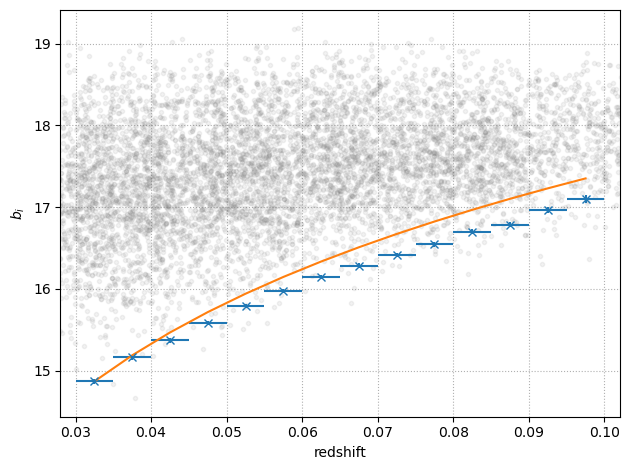

In [36]:
plt.figure(tight_layout=True)

plt.grid(ls=':')

plt.plot(SGA_TF['Z_DESI_CMB'][SGA_TF['MAIN']], 
         SGA_TF['R_MAG_SB26_CORR'][SGA_TF['MAIN']]+1.5, 
         '.', 
         alpha=0.1, 
         c='gray')

plt.errorbar(zc, np.median(tfr_samples[1:-1], axis=1), 
             xerr=0.5*dz, 
             yerr=ZP_err, 
             fmt='x', 
             c='tab:blue')

# plt.plot(zc, mu_zc + mean_ZP*u.mag)
plt.plot(zc, mu_zc + ZP[0]*u.mag, c='tab:orange')

plt.xlim(0.028, 0.102)

plt.xlabel('redshift')
plt.ylabel('$b_i$');

# Plot $B_i$ v. redshift

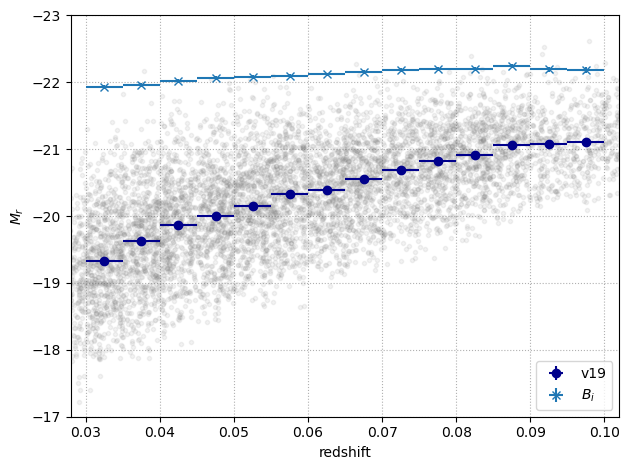

In [34]:
plt.figure(tight_layout=True)

plt.grid(ls=':')

plt.plot(SGA_TF['Z_DESI_CMB'][SGA_TF['MAIN']], 
         SGA_TF['R_ABSMAG_SB26'][SGA_TF['MAIN']], 
         '.', 
         alpha=0.1, 
         c='gray')

# Plot the median absolute magnitude of the galaxies in each redshift bin
N, Mr_avg, Mr_std = profile_histogram(SGA_TF['Z_DESI_CMB'][SGA_TF['MAIN']], 
                                      SGA_TF['R_ABSMAG_SB26'][SGA_TF['MAIN']], 
                                      zbins, 
                                      stat='median')
plt.errorbar(zc, Mr_avg, 
             xerr=0.5*dz, 
             yerr=Mr_std, 
             fmt='o', 
             color='darkblue', 
             label='v19')

plt.errorbar(zc, ZP-1.8, 
             xerr=0.5*dz, 
             yerr=ZP_err, 
             fmt='x', 
             label='$B_i$')

plt.xlim(0.028, 0.102)
plt.ylim(-17, -23)

plt.legend()

plt.xlabel('redshift')
plt.ylabel('$M_r$');